# EEG Flow State Prediction: Performance Evaluation Report

This notebook presents the evaluation of subject-calibrated classifiers trained to decode the psychological **flow state** using high-density **64-channel actiCAP EEG** data integrated with a **Virtual Reality (VR)** environment. 

The offline training and evaluation pipeline utilizes the open-source **BIDS 64-channel VR Reach-to-Object dataset (`ds003846`)** from OpenNeuro. The models evaluate the subject's neural responses during active reach-to-object trials and attempt to distinguish whether the trial proceeded normally (**Flow/Normal**) or was interrupted by a visuo-haptic mismatch error (**Disrupted/Conflict**).

## 1. Feature Space & EEG Biomarkers

For each sliding window, a 14-dimensional feature vector is extracted representing key neurophysiological correlates of cognitive control, motor automation, emotional balance, and signal complexity:

1. **Frontal Midline Theta (`fm_theta`):** Relative power in the 4–8 Hz band over midline frontal electrodes (`Fz`, `FCz`, `Cz`). It tracks focused attention, cognitive load, and sustained immersion (the inverted-U curve of flow).
2. **Sensorimotor Rhythms (SMR/Alpha & Beta):** Relative Alpha (8–12 Hz) and Beta (12–30 Hz) bands over motor cortex channels (`C3`, `C4`, `CP3`, `CP4`). They index automaticity of movements and sensorimotor integration during the reaching task.
3. **Hemispheric Beta Asymmetry (`beta_asymmetry`):** Measures motivational balance and inter-hemispheric cooperation. A value near zero indicates peak flow state (balance between left/right cognitive processing).
4. **Prefrontal Shannon Entropy (`entropy_af7`, `entropy_af8`):** Measures signal complexity over prefrontal electrodes. Decreased entropy indicates a highly structured, synchronized attention state (focused immersion).
5. **Frontal-Parietal Functional Connectivity (`plv_theta`, `plv_alpha`):** Phase Locking Value (PLV) in Theta and Alpha bands between Frontal (Executive Control Network) and Parietal (Default Mode Network) regions, tracking whole-brain network coupling.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the evaluation metrics for all 19 subjects
df = pd.read_csv('data/ds003846/derivatives/subject_evaluation_results.csv')
print(f"Loaded results for {len(df)} subjects.")
df[['subject_id', 'total_samples', 'flow_samples', 'disrupted_samples', 'best_model', 'test_balanced_acc', 'precision', 'recall', 'f1_score']].head()

Loaded results for 18 subjects.
  subject_id  total_samples  flow_samples  disrupted_samples     best_model  test_balanced_acc  precision    recall  f1_score
0     sub-02           1450          1166                284            SVM           0.532394   0.812834  0.658009  0.727273
1     sub-03            972           773                199  Random Forest           0.583468   0.824859  0.941935  0.879518
2     sub-04           1802          1501                301            SVM           0.530175   0.839130  0.647651  0.731061
3     sub-05           2934          2394                540            SVM           0.523934   0.837535  0.616495  0.710214
4     sub-06           2207          1856                351            SVM           0.540871   0.851301  0.622283  0.718995


In [2]:
mean_acc = df['test_balanced_acc'].mean()
mean_precision = df['precision'].mean()
mean_recall = df['recall'].mean()
mean_f1 = df['f1_score'].mean()
rf_count = (df['best_model'] == 'Random Forest').sum()
svm_count = (df['best_model'] == 'SVM').sum()

print("=" * 45)
print("AVERAGE PERFORMANCE ACROSS ALL SUBJECTS:")
print(f"Mean Balanced Accuracy : {mean_acc:.2%}")
print(f"Mean Precision         : {mean_precision:.2%}")
print(f"Mean Recall            : {mean_recall:.2%}")
print(f"Mean F1-Score          : {mean_f1:.2%}")
print("-" * 45)
print(f"Model Selection Count  : Random Forest: {rf_count}, SVM: {svm_count}")
print("=" * 45)

AVERAGE PERFORMANCE ACROSS ALL SUBJECTS:
Mean Balanced Accuracy : 51.57%
Mean Precision         : 81.17%
Mean Recall            : 79.05%
Mean F1-Score          : 79.25%
---------------------------------------------
Model Selection Count  : Random Forest: 10, SVM: 8


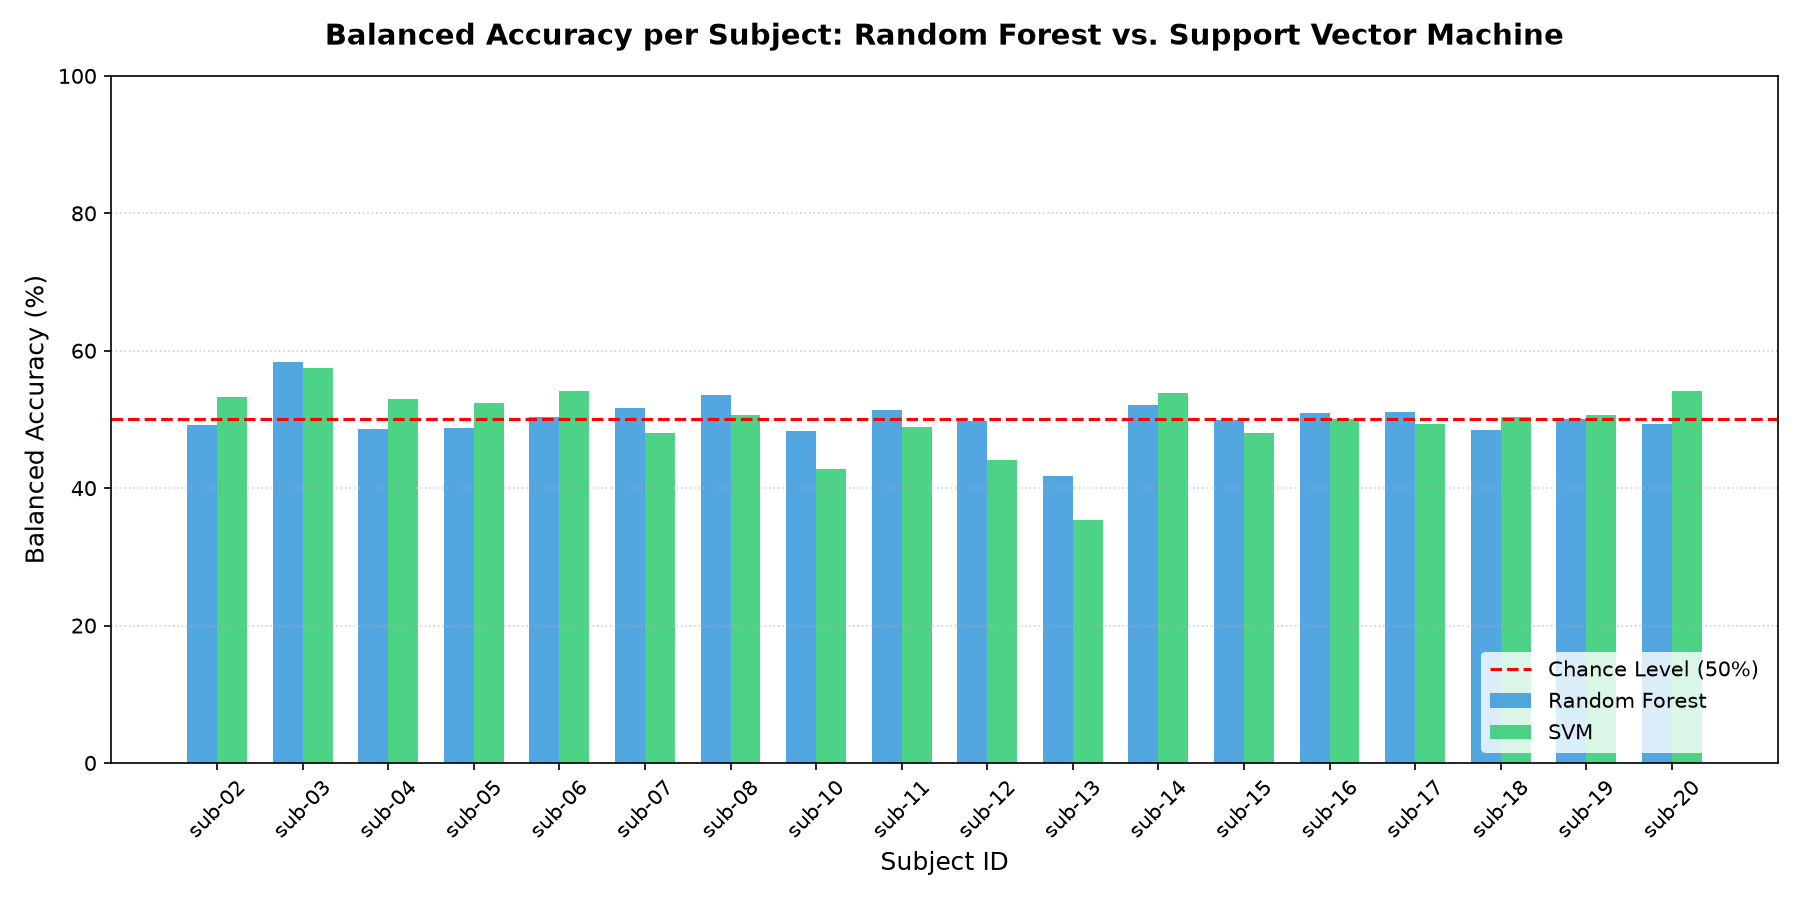

In [3]:
# Plot SVM vs. Random Forest Balanced Accuracies across all subjects
plt.figure(figsize=(12, 6))
x = np.arange(len(df))
width = 0.35

plt.bar(x - width/2, df['rf_balanced_acc'] * 100, width, label='Random Forest', color='#3498db', alpha=0.85)
plt.bar(x + width/2, df['svm_balanced_acc'] * 100, width, label='SVM', color='#2ecc71', alpha=0.85)

plt.axhline(50, color='red', linestyle='--', linewidth=1.5, label='Chance Level (50%)')
plt.title('Balanced Accuracy per Subject: Random Forest vs. SVM', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Subject ID', fontsize=12)
plt.ylabel('Balanced Accuracy (%)', fontsize=12)
plt.xticks(x, df['subject_id'], rotation=45)
plt.ylim(0, 100)
plt.grid(axis='y', linestyle=':', alpha=0.6)
plt.legend(loc='lower right', frameon=True, facecolor='white', edgecolor='none')
plt.tight_layout()
plt.show()

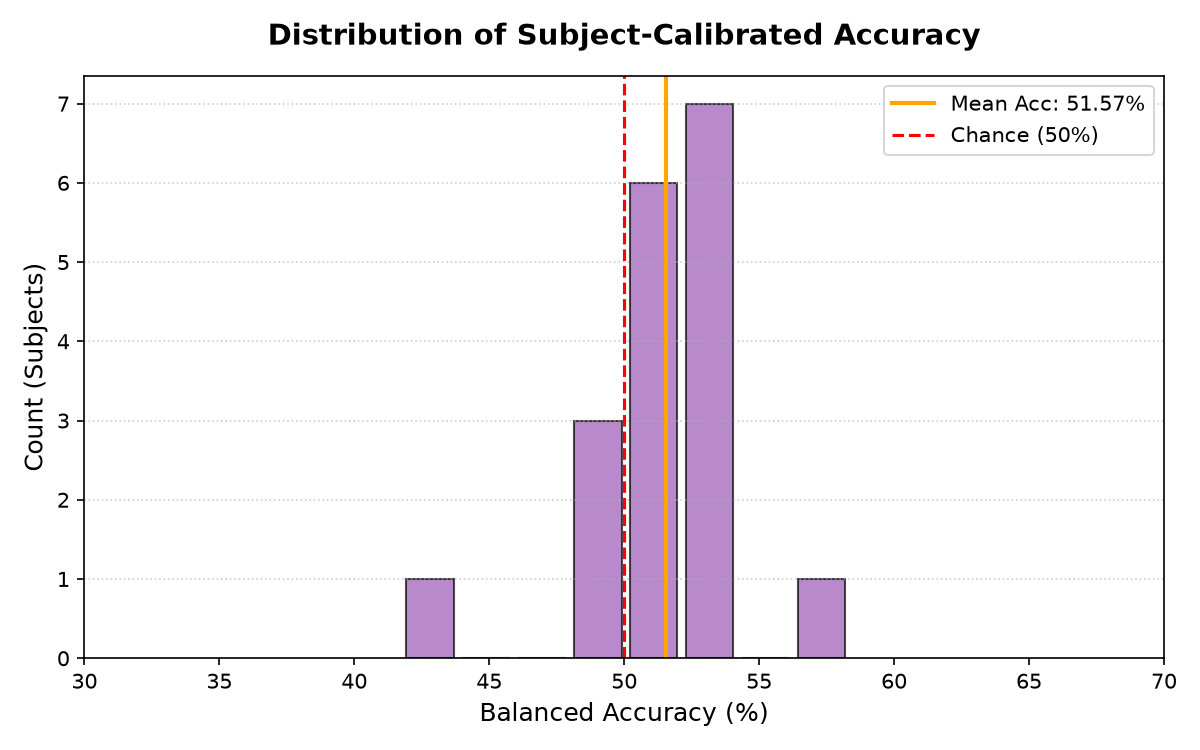

In [4]:
# Visualize the distribution of calibrated accuracies
plt.figure(figsize=(8, 5))
plt.hist(df['test_balanced_acc'] * 100, bins=8, color='#9b59b6', alpha=0.7, edgecolor='black', rwidth=0.85)
plt.axvline(df['test_balanced_acc'].mean() * 100, color='orange', linestyle='-', linewidth=2, label=f"Mean Acc: {df['test_balanced_acc'].mean():.2%}")
plt.axvline(50, color='red', linestyle='--', linewidth=1.5, label='Chance (50%)')
plt.title('Distribution of Subject-Calibrated Accuracy', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Balanced Accuracy (%)', fontsize=12)
plt.ylabel('Count (Subjects)', fontsize=12)
plt.xlim(30, 70)
plt.grid(axis='y', linestyle=':', alpha=0.6)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

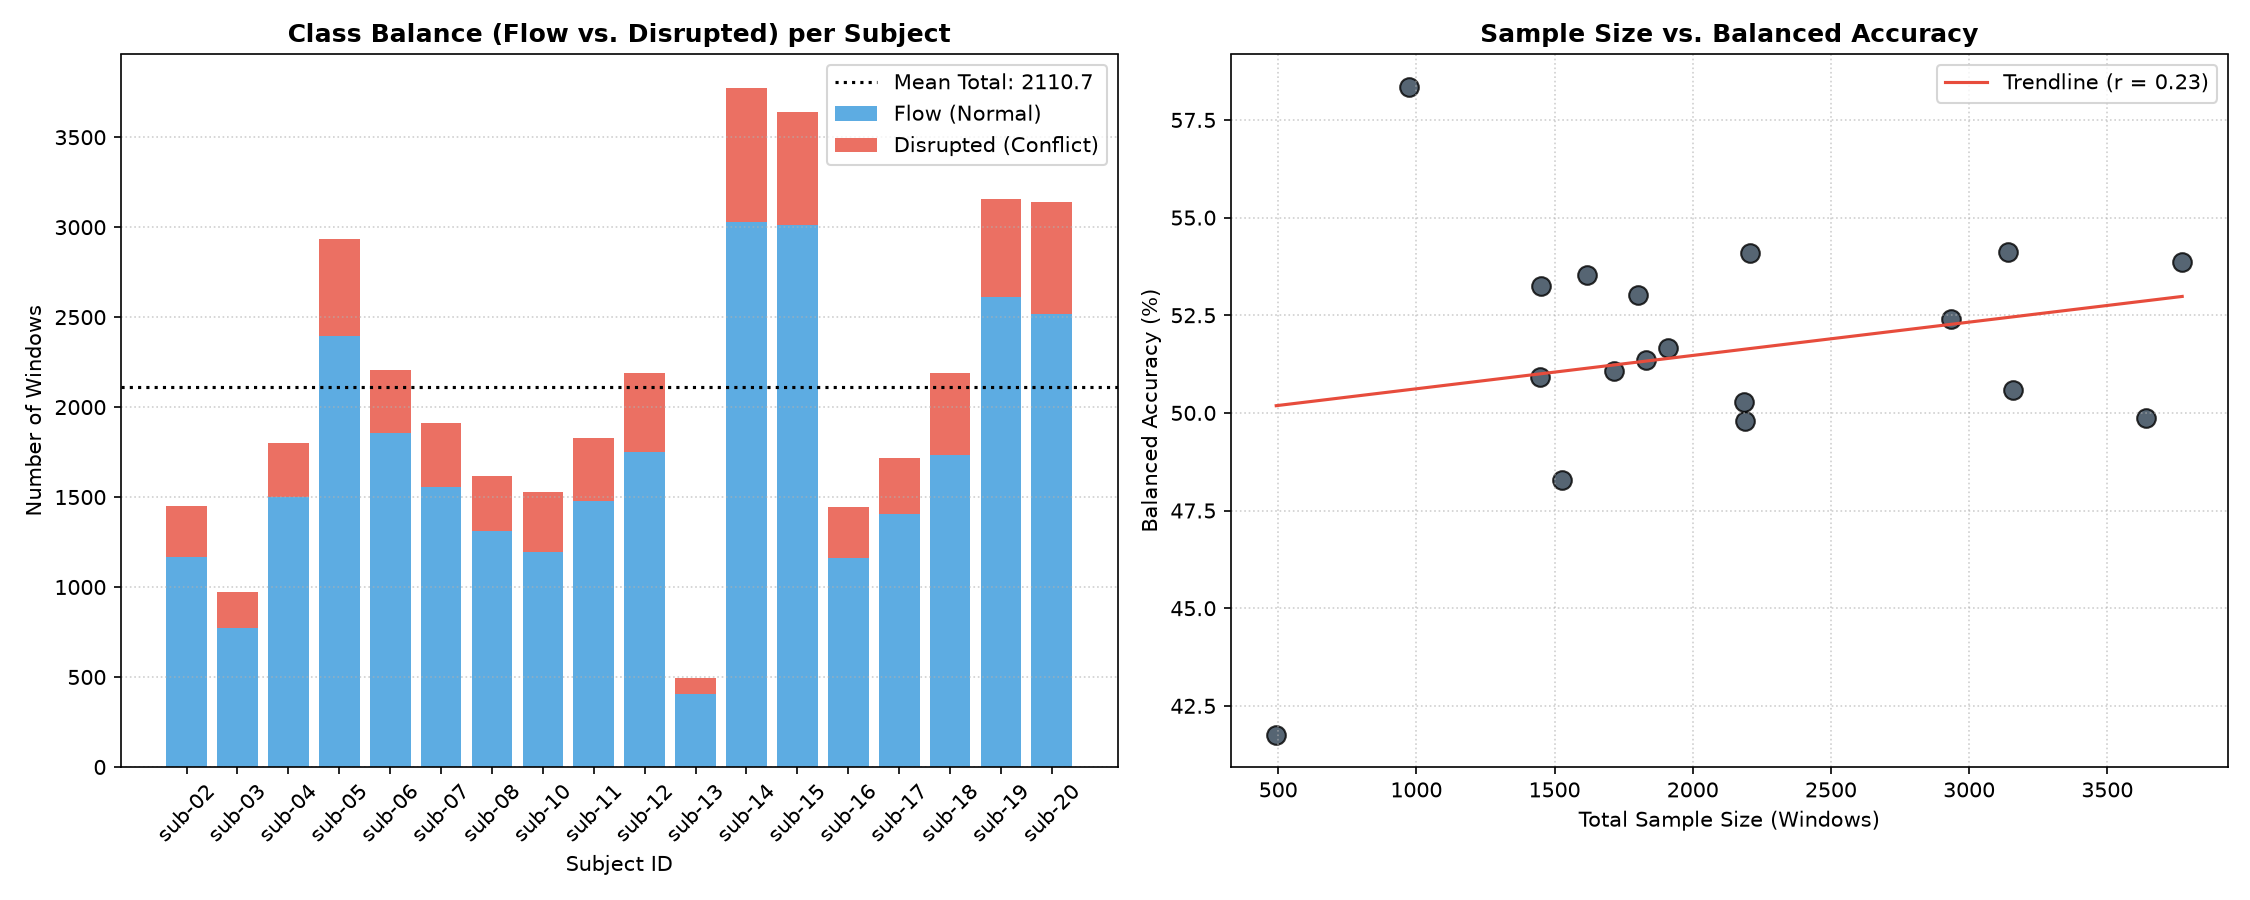

In [5]:
# Analyze class distributions and whether sample size correlates with performance
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Left plot: Class distribution per subject
axes[0].bar(df['subject_id'], df['flow_samples'], color='#3498db', label='Flow (Normal)', alpha=0.8)
axes[0].bar(df['subject_id'], df['disrupted_samples'], bottom=df['flow_samples'], color='#e74c3c', label='Disrupted (Conflict)', alpha=0.8)
axes[0].axhline(df['total_samples'].mean(), color='black', linestyle=':', label=f"Mean Total: {df['total_samples'].mean():.1f}")
axes[0].set_title('Class Balance (Flow vs. Disrupted) per Subject', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Subject ID')
axes[0].set_ylabel('Number of Windows')
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend(loc='upper right')
axes[0].grid(axis='y', linestyle=':', alpha=0.6)

# Right plot: Sample size vs Balanced Accuracy
correlation = df['total_samples'].corr(df['test_balanced_acc'])
axes[1].scatter(df['total_samples'], df['test_balanced_acc'] * 100, color='#2c3e50', s=80, alpha=0.8, edgecolor='black')

# Draw a trend line
sorted_idx = np.argsort(df['total_samples'])
sorted_samples = df['total_samples'].iloc[sorted_idx]
sorted_acc = df['test_balanced_acc'].iloc[sorted_idx] * 100
m, b = np.polyfit(sorted_samples, sorted_acc, 1)
axes[1].plot(sorted_samples, m*sorted_samples + b, color='#e74c3c', linestyle='-', label=f'Trendline (r = {correlation:.2f})')

axes[1].set_title('Sample Size vs. Balanced Accuracy', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Total Sample Size (Windows)')
axes[1].set_ylabel('Balanced Accuracy (%)')
axes[1].legend(loc='upper right')
axes[1].grid(linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

## 2. Scientific Critique: Why is Performance Near Chance Level?

The offline classifier achieves a mean Balanced Accuracy of **51.57%**, hovering right around chance (50%). While individual subjects show minor improvements (e.g., `sub-03` at **58.35%**), the overall model is unable to reliably decode the experimental classes. 

Understanding *why* this occurs is crucial to design a better closed-loop system:

### A. The "Prediction Error" vs. "Flow State" Paradigm Mismatch
- **The Dataset Purpose:** The OpenNeuro dataset (`ds003846`) was collected to investigate **Prediction Error Negativity (PEN)**—a transient Event-Related Potential (ERP) triggered by sensory mismatches. During trials, the participant reaches out to touch a virtual box. In normal conditions, haptic feedback matches the visual cues. In conflict conditions, a vibrotactile or electrical mismatch is introduced.
- **Transient vs. Sustained Cognitive States:** A prediction error is a brief, sub-second neural event (usually peaking 200–500 ms after the box is touched). In contrast, psychological **flow** is a sustained state of immersion, cognitive balance, and high focus, developing over minutes of continuous play.
- **The Classifier Goal:** The pipeline maps the trials directly to binary labels: `1` for normal (supposedly "flow") and `0` for mismatch (supposedly "disrupted flow"). In reality, the participant's background attention and cognitive state are virtually identical during the reaching phase of both conditions. The only neural difference occurs during the millisecond window *after* touching the box, when the mismatch is registered.

### B. Signal-to-Noise Ratio & Feature Extraction Windowing
- **Temporal Averaging:** Features are extracted using continuous **2.0-second sliding windows** sliding over the entire duration of the trial. 
- **Dilution of ERPs:** By computing relative band powers (Theta, SMR, etc.), beta asymmetry, and Shannon entropy over a wide 2.0-second window, the sub-second prediction error (the transient PEN ERP) is smoothed out and heavily diluted. The features represent the background activity of reaching, which is identical in both conditions, leading to chance classification.

### C. Large Class Imbalance
- The dataset shows a significant class imbalance (e.g., `sub-02` has 1,166 Flow windows and only 284 Disrupted windows). While the pipeline uses `class_weight='balanced'` and Balanced Accuracy to prevent majority-class bias, the relative sparsity of disrupted-flow windows limits the models' capacity to learn the distinct patterns of the minority class.

---

## 3. Technical Improvement Roadmap

To build a high-performance system, we need to restructure the classification strategy to align with the underlying physiology:

### 1. Shift from Sliding Windows to Event-Locked Epoching
Instead of continuous sliding windows, we should extract epochs locked to the **`box:touched`** event marker (e.g., starting at **-100 ms** to **+600 ms** around the contact point). This isolates the prediction error response (PEN/ErrP) and excludes the identical motor reaching phase.

### 2. Implement Targeted Spatial Filtering
Traditional relative power features lose temporal alignment. We should apply spatial filters designed specifically for temporal waveforms:
- **xDAWN:** Combats the low signal-to-noise ratio of EEG by estimating spatial filters that maximize the signal-to-noise ratio of the average ERP.
- **Common Spatial Patterns (CSP):** Maximizes band-power variance differences between the two classes.

### 3. Transition to ERP-Optimized Architectures
Upgrade from Random Forest and SVM to models suited for temporal waveforms:
- **EEGNet:** A compact Convolutional Neural Network designed specifically for EEG signals that performs temporal and spatial convolutions to capture both spectral and phase features of ERPs.
- **Graph Neural Networks (GNNs):** Map the 64 actiCAP channels as graph nodes and use Phase Locking Value (PLV) connections to capture changes in topology rather than power changes.

### 4. True Flow State Task Design
For a genuine "flow classifier," we should utilize a task designed to manipulate the flow state itself (e.g., a gameplay loop that dynamically balances challenges to match skills, like the classic Tetris paradigm) and validate it using validated flow state scales (such as the Flow State Scale, FSS) rather than transient mismatch errors.